# M2.Ex2: Automobile Fuel Efficiency

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M2/exercises/ex2_multi-reg.ipynb)

In [45]:
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
import numpy as np


## Auto MPG Dataset

The Auto MPG Dataset is a classic benchmark for regression analysis in machine learning. It originally appeared in the 1983 American Statistical Association (ASA) Exposition and was later donated to the UCI Machine Learning Repository by Ross Quinlan in 1993.

The data consists of technical specifications for various car models from the late 1970s and early 1980s, primarily used to predict fuel efficiency (MPG).

- Features: `5` numerical, `3` categorical
- Target: `mpg` (miles per gallon)
- Size: `398` samples
- Source: [Auto MPG Dataset](https://archive.ics.uci.edu/dataset/9/auto+mpg)

### Step 1. Load the data

In [46]:
df=pd.read_csv("../../content/datasets/auto-mpg.csv")
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


### Step 2.a Assign variables `X` to the features and `y` to the target

In [47]:
x = df[['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model year', 'origin', 'car name']]
y = df['mpg']

### Step 2.b print the type of each

In [48]:
print(type(x))
x.dtypes

<class 'pandas.DataFrame'>


cylinders         int64
displacement    float64
horsepower          str
weight            int64
acceleration    float64
model year        int64
origin            int64
car name            str
dtype: object

In [49]:
print(type(y))
y.dtypes

<class 'pandas.Series'>


dtype('float64')

### Step 2.c identify whether the target is categorical or numerical & whether the task is regression or classification

In [50]:
#they are nemrical both x and y , and the target is regression 

### Step 3. Identify the number of samples and columns of both the data matrix and the target

In [51]:
print(x.shape)
print(y.shape)

(398, 8)
(398,)


### Step 4. Summarize the distribution of the data

- Use `describe()` for numerical features
- Use `describe()` for cateogrical features

In [52]:
df.describe(exclude= 'object')


,mpg,cylinders,displacement,weight,acceleration,model year,origin
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,5140.000000,24.800000,82.000000,3.000000


In [53]:
df.describe(include='object')

/var/folders/v6/4v1dj_sd7s7fs6l6c7wpdcy00000gn/T/ipykernel_66349/87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,horsepower,car name
count,398,398
unique,94,305
top,150,ford pinto
freq,22,6


### Step 5. Plot each of the features vs the target

Hint use this: `sns.pairplot(adv,x_vars=['TV','Radio','Newspaper'],y_vars='Sales',height=6,aspect=0.7,kind='reg')`

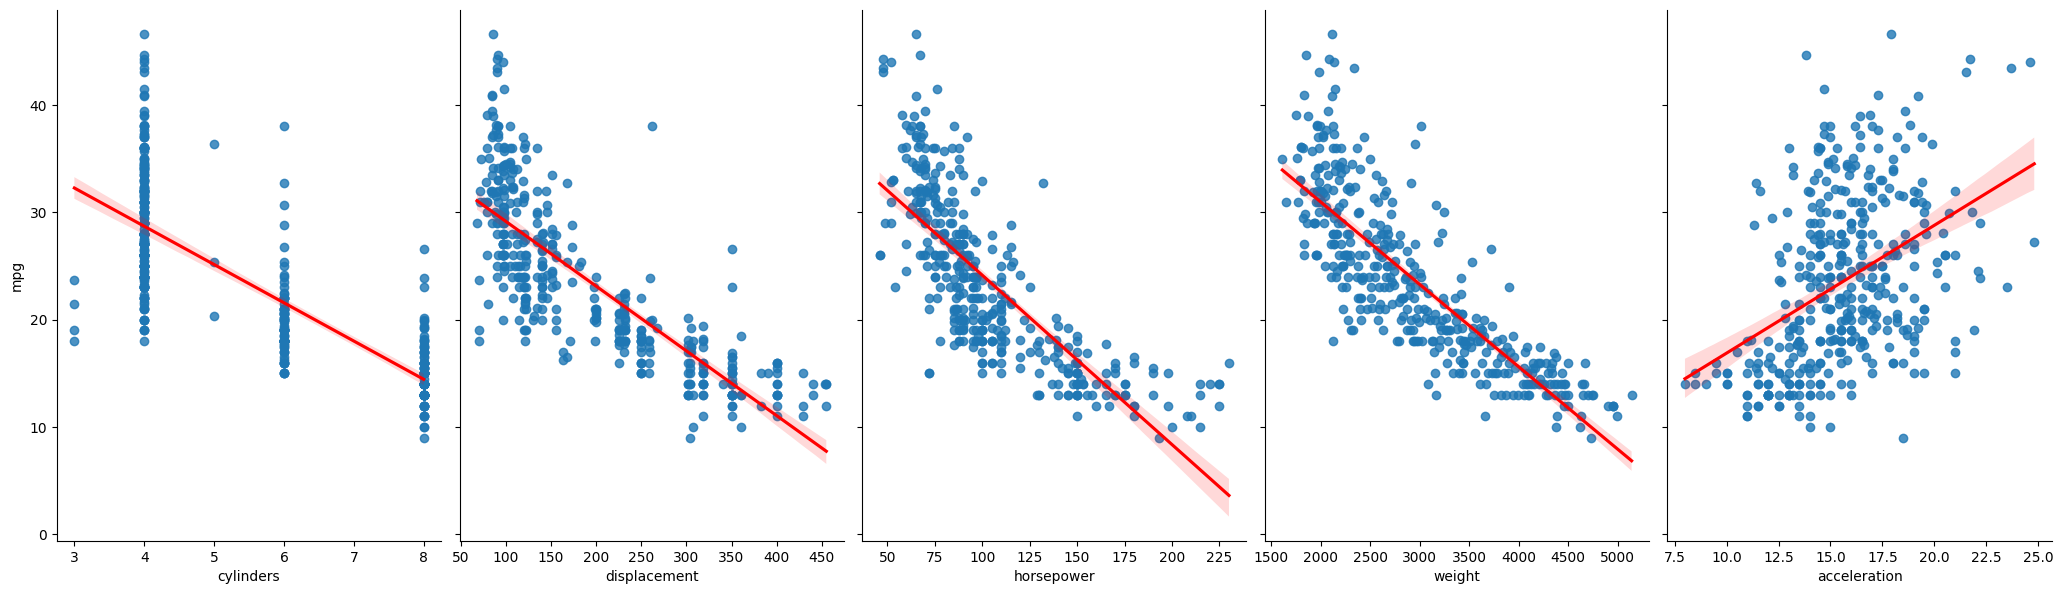

In [54]:
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')

sns.pairplot(
    data=df,
    x_vars=['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration'],
    y_vars='mpg',
    height=6,
    aspect=0.7,
    kind='reg',
    plot_kws={'line_kws':{'color':'red'}}
    )


### Step 6. What is the relationship between the feature and the target? (increasing or decreasing or none)

1. `x=cylinders` and `y=mpg`
2. `x=displacement` and `y=mpg`
3. `x=horsepower` and `y=mpg`
4. `x=weight` and `y=mpg`
5. `x=acceleration` and `y=mpg`

In [55]:
#1- is decreasing
#2- is decreasing
#3- is decreasing
#4- is decreasing
#5- is increasing


### Step 7. Define the pipeline with pre-processing steps

Raw data is rarely ready for use in ML models. We often need steps such as:

- Handling missing values
- Encoding categorical variables
- Scaling numerical variables

Use `ColumnTransformer` to separate the preprocessing steps of the numerical features from the categorical ones.


In [56]:
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')
df = df.dropna(subset=['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'mpg'])
df.replace('?', np.nan, inplace=True)
df['horsepower'] = pd.to_numeric(df['horsepower'])

In [57]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

num_features = ['cylinders','displacement', 'horsepower', 'weight', 'acceleration']
cat_features = [ 'model year', 'origin']

num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', num_transformer, num_features),
    ('cat', cat_transformer, cat_features)
])

predictor = LinearRegression()

In [58]:
pipe = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", predictor),
    ]
)

### Step 8. Split the dataset into train and test sets

In [62]:
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')  

print(df['horsepower'].dtype)  
print(df['horsepower'].isna().sum())  

float64
0


In [63]:
X = df[num_features + cat_features]
y = df['mpg']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Step 9.a Fit the pipeline on the training set

In [64]:
pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

### Step 9.b Identify the learned coefficients (for each feature) and the bias term

In [65]:
print(f"Coefficients: {pipe.named_steps['regressor'].coef_}")
print(f"Intercept: {pipe.named_steps['regressor'].intercept_}")

Coefficients: [-0.09405533  1.26484161 -0.9827328  -4.93207776  0.08111085 -3.39491597
 -2.07160261 -3.20394155 -3.80932857 -1.24744969 -2.61361027 -1.27952417
  0.23629826  0.2252918   1.93792204  6.09804489  3.80413954  5.31867629
 -1.70290101  0.79770485  0.90519616]
Intercept: 24.320991660989876


### Step 9.c how much `mpg` we gain if we decrease the weight of the automobile by `100kg`?

In [69]:
weight_coef = pipe.named_steps['regressor'].coef_[3]

mpg_gain = weight_coef * -100
print(f"MPG gain from decrease 100kg weight: {mpg_gain:.4f} mpg")

MPG gain from decrease 100kg weight: 493.2078 mpg


### Step 10. Evaluate the pipeline on the test set

In [71]:
score = pipe.score(X_test, y_test)
print(f"The score : {score:.4%}")

The score : 83.7093%
